In [14]:
from search import *
import random

class QueensLocalSearch(Problem):
    def __init__(self, n=8):
        self.n = n
        initial = tuple(random.randint(0, n - 1) for _ in range(n))
        super().__init__(initial)

    def actions(self, state):
        return [
            (col, row)
            for col in range(self.n)
            for row in range(self.n)
            if row != state[col]
        ]

    def result(self, state, action):
        col, row = action
        new_state = list(state)
        new_state[col] = row
        return tuple(new_state)

    def conflicts(self, state):
        conflicts = 0

        for i in range(self.n):
            for j in range(i + 1, self.n):
                same_row = state[i] == state[j]
                same_diagonal = abs(state[i] - state[j]) == abs(i - j)

                if same_row or same_diagonal:
                    conflicts += 1

        return conflicts

    def goal_test(self, state):
        return self.conflicts(state) == 0

    def value(self, state):
        max_pairs = self.n * (self.n - 1) // 2
        return max_pairs - self.conflicts(state)
    
    

def slow_schedule(t):
    if t > 300:
        return 0
    return 20 * (0.95 ** t)

def run_queens_experiments(num_trials=100):
    results = {
        "steepest": 0,
        "random_restart": 0,
        "annealing": 0
    }

    for _ in range(num_trials):

        problem = QueensLocalSearch(8)
        result = hill_climbing(problem)
        if problem.goal_test(result):
            results["steepest"] += 1

        problem = QueensLocalSearch(8)
        result = simulated_annealing(problem, schedule=slow_schedule)
        if problem.goal_test(result):
            results["annealing"] += 1

        solved = False
        for _ in range(10):
            problem = QueensLocalSearch(8)
            result = hill_climbing(problem)

            if problem.goal_test(result):
                solved = True
                break

        if solved:
            results["random_restart"] += 1

    return results

In [15]:
class PuzzleWithValue(EightPuzzle):
    def value(self, state):
        distance = 0
        goal = (1,2,3,4,5,6,7,8,0)

        for i in range(9):
            if state[i] == 0:
                continue

            goal_index = goal.index(state[i])
            x1, y1 = divmod(i, 3)
            x2, y2 = divmod(goal_index, 3)

            distance += abs(x1 - x2) + abs(y1 - y2)

        return -distance


def random_puzzle(moves=50):
    problem = EightPuzzle((1,2,3,4,5,6,7,8,0))
    state = problem.initial

    for _ in range(moves):
        actions = problem.actions(state)
        state = problem.result(state, random.choice(actions))

    return state


def get_optimal_cost(state):
    problem = EightPuzzle(state)
    result = astar_search(problem)
    if result is None:
        return None
    return len(result.solution())


def puzzle_schedule(t):
    if t > 300:
        return 0
    return 10 * (0.95 ** t)

def run_puzzle_experiments(num_trials=50):
    results = []

    for _ in range(num_trials):
        state = random_puzzle()

        optimal_cost = get_optimal_cost(state)
        if optimal_cost is None:
            continue

        # Hill Climbing
        problem = PuzzleWithValue(state)
        hc_result = hill_climbing(problem)
        hc_solved = problem.goal_test(hc_result)

        # Simulated Annealing
        problem = PuzzleWithValue(state)
        sa_result = simulated_annealing(problem, schedule=puzzle_schedule)
        sa_solved = problem.goal_test(sa_result)

        # Random Restart
        rr_solved = False
        for _ in range(10):
            problem = PuzzleWithValue(state)
            rr_result = hill_climbing(problem)
            if problem.goal_test(rr_result):
                rr_solved = True
                break

        results.append({
            "hc_solved": hc_solved,
            "sa_solved": sa_solved,
            "rr_solved": rr_solved
        })

    return results

In [16]:
queens_results = run_queens_experiments(100)
puzzle_results = run_puzzle_experiments(50)


In [17]:
print("=== 8-Queens Results ===")
for k, v in queens_results.items():
    print(f"{k}: {v/100:.2f} success rate")

print("\n=== 8-Puzzle Results ===")

hc_success = sum(1 for r in puzzle_results if r["hc_solved"]) / len(puzzle_results)
sa_success = sum(1 for r in puzzle_results if r["sa_solved"]) / len(puzzle_results)
rr_success = sum(1 for r in puzzle_results if r["rr_solved"]) / len(puzzle_results)

print(f"Hill Climbing success: {hc_success:.2f}")
print(f"Simulated Annealing success: {sa_success:.2f}")
print(f"Random Restart success: {rr_success:.2f}")

=== 8-Queens Results ===
steepest: 0.16 success rate
random_restart: 0.70 success rate
annealing: 0.30 success rate

=== 8-Puzzle Results ===
Hill Climbing success: 0.24
Simulated Annealing success: 0.10
Random Restart success: 0.28


ANALisys:

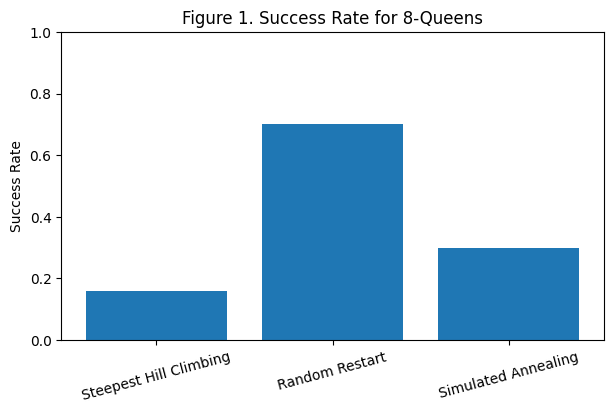

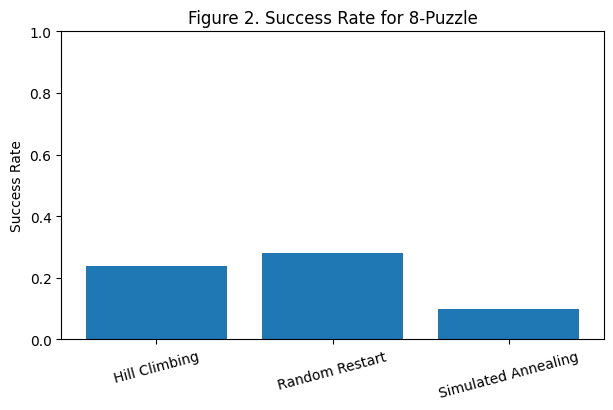

In [18]:
import matplotlib.pyplot as plt

queens_algorithms = [
    "Steepest Hill Climbing",
    "Random Restart",
    "Simulated Annealing"
]

queens_success = [
    queens_results["steepest"] / 100,
    queens_results["random_restart"] / 100,
    queens_results["annealing"] / 100
]

hc_success = sum(1 for r in puzzle_results if r["hc_solved"]) / len(puzzle_results)
sa_success = sum(1 for r in puzzle_results if r["sa_solved"]) / len(puzzle_results)
rr_success = sum(1 for r in puzzle_results if r["rr_solved"]) / len(puzzle_results)

puzzle_algorithms = [
    "Hill Climbing",
    "Random Restart",
    "Simulated Annealing"
]

puzzle_success = [
    hc_success,
    rr_success,
    sa_success
]

plt.figure(figsize=(7,4))
plt.bar(queens_algorithms, queens_success)
plt.title("Figure 1. Success Rate for 8-Queens")
plt.ylabel("Success Rate")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(7,4))
plt.bar(puzzle_algorithms, puzzle_success)
plt.title("Figure 2. Success Rate for 8-Puzzle")
plt.ylabel("Success Rate")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.show()